# Speech Services Comparison

This notebook compare the speech services from three main cloud providers. 


In [1]:
from pathlib import Path
import sqlite3
import time

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from speech import AWSSpeech, AzureSpeech, GoogleSpeech


In [2]:
db = sqlite3.connect("project-2.sqlite")

df_speeches = pd.read_sql("SELECT * FROM speech", db)
df_speeches.head()

,id,id_speech_type,speech
0,1,CC,"Olá, tudo bem?"
1,2,CC,Bom dia!
2,3,CC,Até logo.
3,4,CC,"Sim, claro."
4,5,CC,Não sei.


In [3]:
output_path = Path("output/")
audio_path = lambda provider, id: str(output_path / f"{provider}_{id:02d}.mp3")

In [4]:
aws_speech = AWSSpeech()
azure_speech = AzureSpeech()
google_speech = GoogleSpeech()

In [5]:
def measuring_call(id, provider, text_to_speak) -> tuple[str, float, float]:
    """Calls the TTS provider and measures CPU and wall time."""
    output_file = audio_path(provider, id)
    cpu0, wall0 = time.process_time(), time.perf_counter()
    match provider:
        case "aws":
            aws_speech.synthesize(text=text_to_speak, 
                                    output_filepath=output_file)
        case "azure":
            azure_speech.synthesize(text=text_to_speak, 
                                    output_filepath=output_file)
        case "google":
            google_speech.synthesize(prompt="Be enthusiastic!",
                                    text=text_to_speak, 
                                    output_filepath=output_file)
    cpu = time.process_time() - cpu0; wall = time.perf_counter() - wall0

    return output_file, cpu, wall


def measuring_call_for_all_providers(id, text_to_speak) -> pd.DataFrame:
    """Calls all TTS providers for the given text and measures CPU and wall time."""
    records = []
    for provider in ["aws", "azure", "google"]:
        output_file, cpu, wall = measuring_call(id, provider, text_to_speak)
        records.append({
            "id_speech": id,
            "provider": provider,
            "output_file": output_file,
            "cpu_time": cpu,
            "wall_time": wall
        })
    return pd.DataFrame.from_records(records)

In [13]:
df_results = pd.DataFrame()

for i in df_speeches.itertuples(index=False):
    try:
        text_to_speak = df_speeches.loc[i.id]["speech"]
        df_tmp = measuring_call_for_all_providers(i.id, text_to_speak)

        time.sleep(1)  # To avoid hitting rate limits
        df_results = pd.concat([df_results, df_tmp], ignore_index=True)
    
    except Exception as e:
        print(f"Error processing id {i.id}: {e}")
        continue

df_results

Error processing id 11: 400 Unable to generate audio. Please make sure both the prompt and the text contain no sensitive or harmful content and try again.
Error processing id 12: 400 Unable to generate audio. Please make sure both the prompt and the text contain no sensitive or harmful content and try again.
Error processing id 12: 400 Unable to generate audio. Please make sure both the prompt and the text contain no sensitive or harmful content and try again.
Error processing id 28: 400 Unable to generate audio. Please make sure both the prompt and the text contain no sensitive or harmful content and try again.
Error processing id 28: 400 Unable to generate audio. Please make sure both the prompt and the text contain no sensitive or harmful content and try again.
Error processing id 40: 40
Error processing id 40: 40


,id_speech,provider,output_file,cpu_time,wall_time
0,1,aws,output\aws_01.mp3,0.171875,0.748450
1,1,azure,output\azure_01.mp3,0.046875,2.060947
2,1,google,output\google_01.mp3,0.203125,3.941199
3,2,aws,output\aws_02.mp3,0.015625,0.130728
4,2,azure,output\azure_02.mp3,0.031250,1.325793
...,...,...,...,...,...
103,38,azure,output\azure_38.mp3,0.000000,1.193336
104,38,google,output\google_38.mp3,0.000000,4.229957
105,39,aws,output\aws_39.mp3,0.015625,0.233637
106,39,azure,output\azure_39.mp3,0.046875,1.178674


In [16]:
df_results['latency_time'] = df_results['wall_time'] - df_results['cpu_time']
df_results

,id_speech,provider,output_file,cpu_time,wall_time,latency_time
0,1,aws,output\aws_01.mp3,0.171875,0.748450,0.576575
1,1,azure,output\azure_01.mp3,0.046875,2.060947,2.014072
2,1,google,output\google_01.mp3,0.203125,3.941199,3.738074
3,2,aws,output\aws_02.mp3,0.015625,0.130728,0.115103
4,2,azure,output\azure_02.mp3,0.031250,1.325793,1.294543
...,...,...,...,...,...,...
103,38,azure,output\azure_38.mp3,0.000000,1.193336,1.193336
104,38,google,output\google_38.mp3,0.000000,4.229957,4.229957
105,39,aws,output\aws_39.mp3,0.015625,0.233637,0.218012
106,39,azure,output\azure_39.mp3,0.046875,1.178674,1.131799


In [17]:
df_results.to_sql("results", db, if_exists="replace", index=True)

108

In [19]:
df_results.groupby("provider").agg(
    median_cpu_time=pd.NamedAgg(column="cpu_time", aggfunc="median"),
    median_latency_time=pd.NamedAgg(column="latency_time", aggfunc="median")
)

,median_cpu_time,median_latency_time
provider,,
aws,0.00000,0.233879
azure,0.03125,1.206933
google,0.00000,4.587266


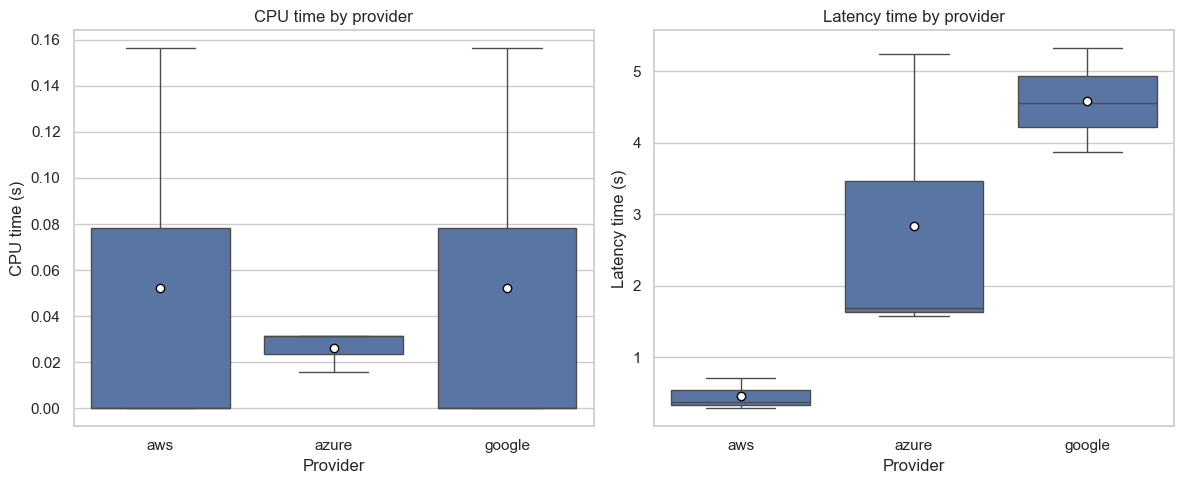

In [20]:
# Boxplots of CPU and Latency times grouped by provider

# Ensure required columns exist
required_cols = {"provider", "cpu_time", "latency_time"}
missing = required_cols - set(df_results.columns)
if missing:
    raise ValueError(f"df_results is missing required columns: {missing}")

# Set a clean theme
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CPU time boxplot
sns.boxplot(
    data=df_results,
    x="provider",
    y="cpu_time",
    ax=axes[0],
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 6},
)
axes[0].set_title("CPU time by provider")
axes[0].set_xlabel("Provider")
axes[0].set_ylabel("CPU time (s)")

# Latency time boxplot
sns.boxplot(
    data=df_results,
    x="provider",
    y="latency_time",
    ax=axes[1],
    showmeans=True,
    meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 6},
)
axes[1].set_title("Latency time by provider")
axes[1].set_xlabel("Provider")
axes[1].set_ylabel("Latency time (s)")

plt.tight_layout()
plt.show()